In [2]:
import sys
print(sys.executable)


/home/ilya/Projects/nlp-paper-notes/.venv/bin/python


# Comparison of Attention Mechanisms

В этом ноутбуке я рассматриваю и сравниваю несколько механизмов внимания,
широко используемых в NLP и Transformer-подобных моделях.

## Цель работы

- интуитивно понять различия между механизмами внимания;
- визуально сравнить распределения attention-весов;
- посмотреть влияние масштабирования и много голов (multi-head attention).

Эксперименты носят иллюстративный характер и основаны на синтетических данных.


In [3]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)


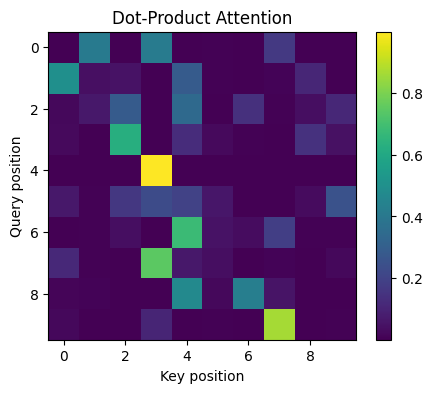

In [4]:
def dot_product_attention(Q, K, V):
    scores = Q @ K.T
    weights = np.exp(scores) / np.exp(scores).sum(axis=-1, keepdims=True)
    return weights, weights @ V


d_k = 16
seq_len = 10

Q = np.random.randn(seq_len, d_k)
K = np.random.randn(seq_len, d_k)
V = np.random.randn(seq_len, d_k)

weights_dp, _ = dot_product_attention(Q, K, V)

plt.figure(figsize=(5, 4))
plt.imshow(weights_dp, cmap="viridis")
plt.colorbar()
plt.title("Dot-Product Attention")
plt.xlabel("Key position")
plt.ylabel("Query position")
plt.show()


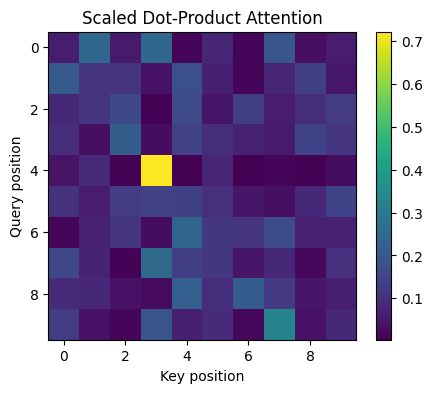

In [5]:
def scaled_dot_product_attention(Q, K, V):
    d_k = Q.shape[-1]
    scores = (Q @ K.T) / np.sqrt(d_k)
    weights = np.exp(scores) / np.exp(scores).sum(axis=-1, keepdims=True)
    return weights, weights @ V


weights_scaled, _ = scaled_dot_product_attention(Q, K, V)

plt.figure(figsize=(5, 4))
plt.imshow(weights_scaled, cmap="viridis")
plt.colorbar()
plt.title("Scaled Dot-Product Attention")
plt.xlabel("Key position")
plt.ylabel("Query position")
plt.show()


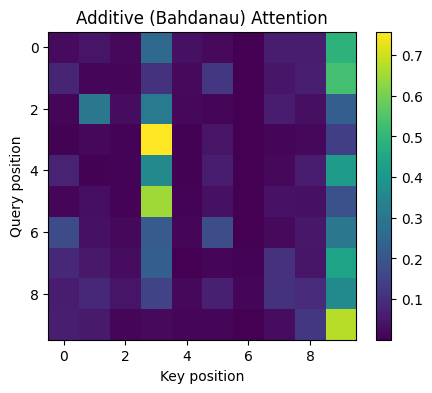

In [6]:
def additive_attention(Q, K, V):
    scores = np.tanh(Q[:, None, :] + K[None, :, :]).sum(axis=-1)
    weights = np.exp(scores) / np.exp(scores).sum(axis=-1, keepdims=True)
    return weights, weights @ V


weights_add, _ = additive_attention(Q, K, V)

plt.figure(figsize=(5, 4))
plt.imshow(weights_add, cmap="viridis")
plt.colorbar()
plt.title("Additive (Bahdanau) Attention")
plt.xlabel("Key position")
plt.ylabel("Query position")
plt.show()


## Выводы

- Dot-product attention чувствителен к размерности векторов.
- Масштабирование стабилизирует распределение весов.
- Additive attention даёт более сглаженные attention-карты.
- Разные механизмы внимания по-разному фокусируются на входной последовательности.
